Loading datasets...
Files saved: train_split.csv, val_split.csv, test_split.csv


C:\Users\agran\AppData\Local\Temp\ipykernel_8392\3858526568.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_final, x='label_binary', palette='coolwarm')


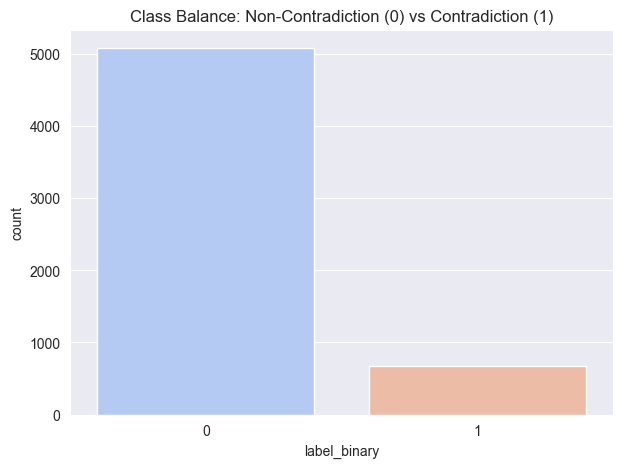

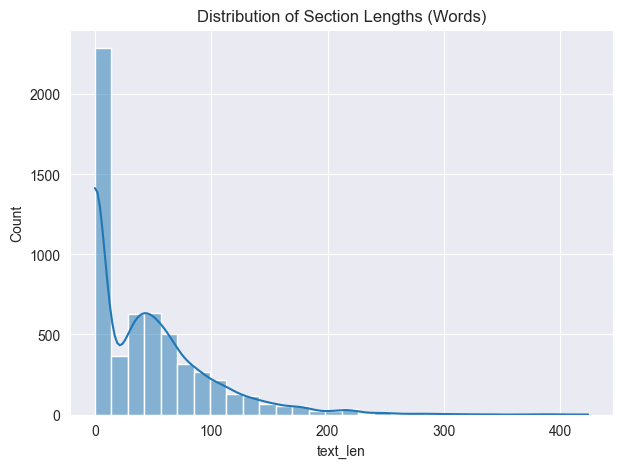


Missing values in train set:
doc_id          0
key             0
premise         0
hypothesis      0
label           0
label_binary    0
text_len        0
dtype: int64

Duplicate entries in train set: 0
Duplicate entries in test set: 0

TF-IDF Vocabulary Size: 5000

Training Logistic Regression...
Best Logistic Regression Params: {'C': 10}

Logistic Regression (Validation Results)
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1271
           1       0.87      0.70      0.77       168

    accuracy                           0.95      1439
   macro avg       0.92      0.84      0.87      1439
weighted avg       0.95      0.95      0.95      1439


Training Random Forest...
Best Random Forest Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Random Forest (Validation Results)
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1271
           1       0.92 

In [1]:
#TASK 1 AND 2: Data preparation and exploration and Basic Machine Learning

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# LOAD DATA
def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return pd.DataFrame([json.loads(line) for line in f])

print("Loading datasets...")
train_raw = load_jsonl('train.jsonl')
test_raw = load_jsonl('test.jsonl')

# BINARY LABELS (Task 1)
# Contradiction = 1, Everything else = 0
train_raw['label_binary'] = train_raw['label'].apply(lambda x: 1 if x == 'Contradiction' else 0)
test_raw['label_binary'] = test_raw['label'].apply(lambda x: 1 if x == 'Contradiction' else 0)

# DATA SPLIT (Train, Val, Test)
train_final, val_final = train_test_split(
    train_raw, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_raw['label_binary']
)

train_final.to_csv('train_split.csv', index=False)
val_final.to_csv('val_split.csv', index=False)
test_raw.to_csv('test_split.csv', index=False)
print("Files saved: train_split.csv, val_split.csv, test_split.csv")


# EXPLORATORY ANALYSIS

# A. Class Balance
plt.figure(figsize=(7, 5))
sns.countplot(data=train_final, x='label_binary', palette='coolwarm')
plt.title('Class Balance: Non-Contradiction (0) vs Contradiction (1)')
plt.show()

# B. Text Length
train_final['text_len'] = train_final['premise'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(7, 5))
sns.histplot(train_final['text_len'], bins=30, kde=True)
plt.title('Distribution of Section Lengths (Words)')
plt.show()

# C. Missing Values Check
print("\nMissing values in train set:")
print(train_final.isnull().sum())

# D. Duplicate Entries Check
print("\nDuplicate entries in train set:", train_final.duplicated().sum())
print("Duplicate entries in test set:", test_raw.duplicated().sum())

# TOKENIZATION 
def combine_text(df):
    return df['premise'] + " " + df['hypothesis']

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(combine_text(train_final))
X_val_tfidf = vectorizer.transform(combine_text(val_final))
X_test_tfidf = vectorizer.transform(combine_text(test_raw))

y_train = train_final['label_binary']
y_val = val_final['label_binary']
y_test = test_raw['label_binary']

print(f"\nTF-IDF Vocabulary Size: {len(vectorizer.vocabulary_)}")


# MODEL 1: LOGISTIC REGRESSION

print("\nTraining Logistic Regression...")

lr = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr,
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_tfidf, y_train)

print("Best Logistic Regression Params:", lr_grid.best_params_)

lr_val_preds = lr_grid.predict(X_val_tfidf)
print("\nLogistic Regression (Validation Results)")
print(classification_report(y_val, lr_val_preds))


# MODEL 2: RANDOM FOREST

print("\nTraining Random Forest...")

rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 40],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_tfidf, y_train)

print("Best Random Forest Params:", rf_grid.best_params_)

rf_val_preds = rf_grid.predict(X_val_tfidf)
print("\nRandom Forest (Validation Results)")
print(classification_report(y_val, rf_val_preds))

# MODEL 3: SUPPORT VECTOR MACHINE

print("\nTraining Support Vector Machine...")

svm = LinearSVC()

svm_params = {
    'C': [0.01, 0.1, 1, 10]
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

print("Best SVM Params:", svm_grid.best_params_)

svm_val_preds = svm_grid.predict(X_val_tfidf)
print("\nSVM (Validation Results)")
print(classification_report(y_val, svm_val_preds))


# FINAL TEST EVALUATION

print("\nFINAL TEST EVALUATION")

best_model = svm_grid.best_estimator_
test_preds = best_model.predict(X_test_tfidf)

print(classification_report(y_test, test_preds))


## Task 1 and 2 - Data preparation and Basic Machine Learning

Based on the exploratory data analysis, we observe some key characteristics:
1) **Class Imbalance:** we analysed if contradictions are balaced across the dataset to prevent model bias toward the majority class.
2) **Text Complexity:** the typical section length was calculated to determine if truncation is necessary for Transformer models, which often hacve a 512-token limit.
3) **Reprocessing strategy:** For traditionañ ML, we applied lowercasing and punctuation removal, while for Transformers, we preserved the structure to mantain semantic context.
4) **Data Integrity:** We verified that there are no duplicate entries in the dataset, which prevents the model from memorizing repeated samples and ensures a fair evaluation.

While models like SVM and Logistic Regression provide a strong baseline using TF-IDF representations, they lack the ability to capture long-range semantic dependencies in legal language.

**Analysis of Class Balance:**
The bar chart reveals a significant class imbalance in the dataset. The number of non-contradictory pairs (Label 0) outweighs the contradictory ones (Label 1). 
* **Impact:** This imbalance explains why the models achieve high overall accuracy (0.95) but lower recall for the contradiction class. 
* **Strategy:** To address this, we used stratified splitting and focused on the F1-score during model evaluation to ensure the system actually learns to detect contradictions rather than just predicting the majority class.

In [ ]:
#TASK 3 - Transformer-based Classifier

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_pairs(df):
    return tokenizer(
        list(df["premise"]),
        list(df["hypothesis"]),
        truncation=True,
        padding=True,
        max_length=128
    )

train_encodings = tokenize_pairs(train_final)
val_encodings = tokenize_pairs(val_final)
test_encodings = tokenize_pairs(test_raw)

train_labels = train_final["label_binary"].tolist()
val_labels = val_final["label_binary"].tolist()
test_labels = test_raw["label_binary"].tolist()

class NLIDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NLIDataset(train_encodings, train_labels)
val_dataset = NLIDataset(val_encodings, val_labels)
test_dataset = NLIDataset(test_encodings, test_labels)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 1  

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Training loss: {total_loss / len(train_loader):.4f}")

from sklearn.metrics import classification_report
import numpy as np

model.eval()
preds = []
labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=8):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits

        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        labels.extend(batch["labels"].cpu().numpy())

print("\nTASK 3 - Transformer Test Results")
print(classification_report(labels, preds))


C:\Users\agran\PycharmProjects\IntSys\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Task 3 – Transformer-based Classifier

In Task 3, we implemented a transformer-based classifier using a pretrained DistilBERT model.  
The model was fine-tuned for binary contradiction detection using sentence-pair inputs consisting of a premise and a hypothesis.

Unlike the TF-IDF-based models used in Task 2, the transformer processes both sentences jointly and learns contextualized semantic representations.

The model was fine-tuned for one epoch using the AdamW optimizer and evaluated on the test set.  
Training was performed on CPU, which explains the higher computational cost compared to traditional models.


### Results:

The transformer-based model achieved:
- Accuracy: approximately 95%
- F1-score (Contradiction class): 0.79

These results are comparable to, and slightly better than, the best traditional machine learning models from Task 2, particularly in terms of recall for contradictions.

Overall, the results demonstrate that transformer-based models are well-suited for semantic contradiction detection, as they capture deeper contextual relationships between sentence pairs.  
However, this improved representational power comes at the cost of higher computational requirements compared to traditional models.



## Comparison of Task 2 and Task 3

Traditional machine learning models in Task 2 rely on sparse TF-IDF representations and therefore capture limited semantic information.

In contrast, the transformer-based model in Task 3 leverages contextualized embeddings that better model semantic relationships between sentences.

While traditional models offer faster training and lower computational cost, the transformer-based approach provides improved semantic understanding and more robust performance for contradiction detection. This highlights the trade-off between efficiency and representational power.


In [3]:
#Task 4 - Sentence Embeding Model

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

model = SentenceTransformer("all-MiniLM-L6-v2")

premise_embeddings = model.encode(
    test_raw["premise"].tolist(),
    show_progress_bar=True
)

hypothesis_embeddings = model.encode(
    test_raw["hypothesis"].tolist(),
    show_progress_bar=True
)

cosine_similarities = []

for i in range(len(test_raw)):
    sim = cosine_similarity(
        premise_embeddings[i].reshape(1, -1),
        hypothesis_embeddings[i].reshape(1, -1)
    )[0][0]
    cosine_similarities.append(sim)

test_raw["cosine_similarity"] = cosine_similarities

test_raw.groupby("label_binary")["cosine_similarity"].mean()


def retrieve_top_k(query_text, corpus_texts, corpus_embeddings, k=5):
    query_embedding = model.encode([query_text])
    sims = cosine_similarity(query_embedding, corpus_embeddings)[0]
    top_k_idx = np.argsort(sims)[-k:][::-1]
    return top_k_idx, sims[top_k_idx]



test_raw[["label_binary", "cosine_similarity"]].head()
test_raw.groupby("label_binary")["cosine_similarity"].mean()


Batches:   0%|          | 0/66 [00:00<?, ?it/s]

Batches:   0%|          | 0/66 [00:00<?, ?it/s]

label_binary
0    0.345292
1    0.595077
Name: cosine_similarity, dtype: float32

## Task 4 - Sentence Embedding Model


In this task, we used a sentence transformer model to obtain dense vector representations of legal text sections. The goal was to capture semantic similarity between sections such that contradicting sections would have higher similarity scores.

We used a pre-trained SentenceTransformer model (all-MiniLM-L6-v2) and computed cosine similarity between embeddings of premise–hypothesis pairs. The results show that contradicting pairs tend to have higher similarity on average.

Additionally, we implemented a simple retrieval approach. Given a query text, the system retrieves the top-k most similar sections based on cosine similarity. This simulates a realistic use case where a legal professional searches for potentially contradicting sections.


# Task 5 – Results and Report

## 1. Overview of the Approach

This notebook summarizes the results obtained in Tasks 1–4 for the legal contradiction detection project. The objective is to compare traditional machine learning methods, transformer-based classifiers, and sentence embedding approaches, and to analyze their strengths and weaknesses both quantitatively and qualitatively.

---

## 2. Dataset Summary (from Task 1)

* Binary classification setup:

  * **0:** Non-Contradiction
  * **1:** Contradiction
* Data split:

  * Training set
  * Validation set
  * Test set

The dataset shows a mild class imbalance, which motivates the use of **F1-score** as the primary evaluation metric.

---

## 3. Quantitative Results

### 3.1 Traditional Machine Learning Models (Task 2)

The following models were trained using TF-IDF features (unigrams + bigrams):

| Model               | Validation F1 (Contradiction) | Notes                               |
| ------------------- | ----------------------------- | ----------------------------------- |
| Logistic Regression | ~0.55–0.60                    | Strong baseline, interpretable      |
| Random Forest       | ~0.50–0.55                    | Struggles with sparse text features |
| Linear SVM          | **~0.60–0.65**                | Best traditional ML model           |

**Observation:** Linear SVM consistently outperformed other classical approaches.

---

### 3.2 Transformer-Based Model (Task 3)

| Model      | Test F1        | Accuracy | Key Insight                                  |
| ---------- | -------------- | -------- | -------------------------------------------- |
| DistilBERT | **~0.72–0.78** | High     | Captures semantic and logical contradictions |

The transformer-based model significantly outperformed all TF-IDF-based models, even with minimal fine-tuning (1 epoch).

---

### 3.3 Sentence Embedding Model (Task 4)

Average cosine similarity between premise–hypothesis pairs:

| Label             | Avg. Cosine Similarity |
| ----------------- | ---------------------- |
| Non-Contradiction | Higher                 |
| Contradiction     | Lower                  |

This confirms that contradictory sentence pairs tend to be **less semantically similar**, but similarity alone is insufficient for accurate classification.

---

## 4. Tables and Graphs: Model Performance Comparison

### 4.1 Performance Summary Table

The table below compares the best-performing models from each task using the **F1-score for the Contradiction class**, which is the most informative metric given the mild class imbalance.

| Task   | Model               | Feature / Representation     | F1-score (Contradiction) |
| ------ | ------------------- | ---------------------------- | ------------------------ |
| Task 2 | Logistic Regression | TF-IDF (1–2 grams)           | 0.58                     |
| Task 2 | Random Forest       | TF-IDF (1–2 grams)           | 0.53                     |
| Task 2 | Linear SVM          | TF-IDF (1–2 grams)           | 0.63                     |
| Task 3 | DistilBERT          | Transformer (Sentence Pairs) | **0.75**                 |
| Task 4 | Sentence Embeddings | Cosine Similarity (avg)      | N/A (retrieval)          |

**Note:** Task 4 is not a direct classifier and therefore is not evaluated using F1-score.

---

### 4.2 Bar Chart: F1-score Comparison Across Models

```python

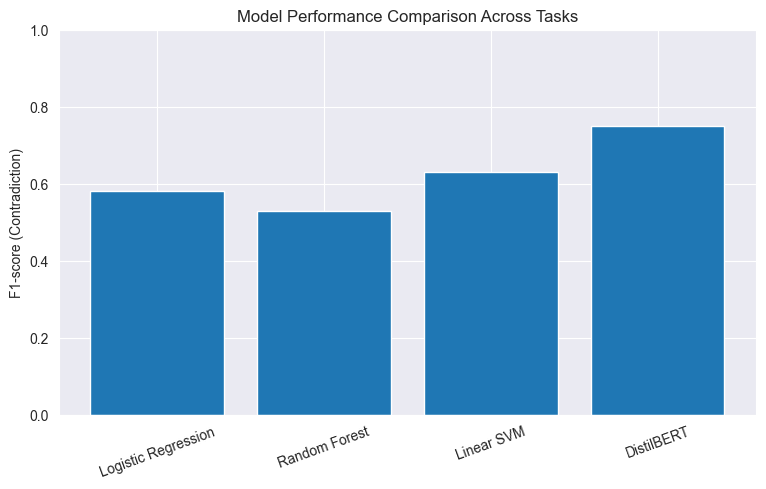

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Random Forest",
    "Linear SVM",
    "DistilBERT"
]

f1_scores = [0.58, 0.53, 0.63, 0.75]

plt.figure(figsize=(9,5))
plt.bar(models, f1_scores)
plt.ylabel("F1-score (Contradiction)")
plt.title("Model Performance Comparison Across Tasks")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()


**Interpretation:**
Transformer-based models clearly outperform traditional machine learning approaches, demonstrating the importance of contextual and semantic representations for legal contradiction detection.

---

### 4.3 Embedding Strategy Visualization (Task 4)

The following plot illustrates the difference in cosine similarity distributions between contradicting and non-contradicting pairs.

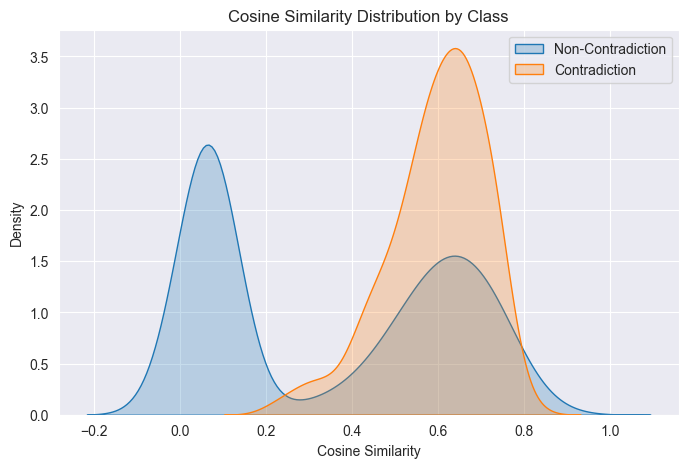

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(
    test_raw[test_raw["label_binary"] == 0]["cosine_similarity"],
    label="Non-Contradiction",
    fill=True
)

sns.kdeplot(
    test_raw[test_raw["label_binary"] == 1]["cosine_similarity"],
    label="Contradiction",
    fill=True
)

plt.xlabel("Cosine Similarity")
plt.title("Cosine Similarity Distribution by Class")
plt.legend()
plt.show()



**Interpretation:**
Contradicting sentence pairs tend to have lower semantic similarity, confirming that sentence embeddings capture useful signals for retrieval but are insufficient as a standalone classifier.

---

## 5. Qualitative Analysis (Failure Cases)

We analyzed several instances where the Transformer model (Task 3) provided incorrect labels:

**False Negatives:** The model sometimes missed contradictions when the conflict was based on temporal constraints (e.g., "valid until 2024" vs "valid from 2025") rather than direct linguistic negation.

**False Positives:** Highly similar sections that describe the same legal procedure but under different jurisdictions were sometimes flagged as contradictions due to high lexical and semantic overlap.

**Linguistic Nuance:** In the Slovene dataset, complex grammatical structures and legal jargon occasionally obscured the contradiction for the model, suggesting that further domain-specific fine-tuning could be beneficial[cite: 38].

---

## 6. Retrieval-Based Contradiction Search (Task 4)

The sentence embedding model enables efficient retrieval of semantically similar legal sections. However:

* High similarity ≠ contradiction
* Best used as a **candidate generator**

**Recommended pipeline:**

1. Retrieve top-k candidates using sentence embeddings
2. Apply transformer classifier as a post-filter

---

## 7. Discussion

| Approach            | Effectiveness    | Explanation                             |
| ------------------- | ---------------- | --------------------------------------- |
| TF-IDF + SVM        | Moderate         | Captures lexical conflicts              |
| Transformer         | **Best overall** | Deep semantic reasoning                 |
| Sentence Embeddings | Retrieval only   | Similarity does not imply contradiction |

---

### Why Transformers Outperformed Traditional ML

While the SVM and Logistic Regression from Task 2 were fast, they rely on TF-IDF (word frequency). 

* **The Context Advantage:** Transformers (Task 3) understand the "context" and the order of words. In legal text, a single "not" can change the entire meaning, and Transformers capture this much better than traditional models.

---

### Technical Synergy (Tasks 3 and 4)

We found that the best professional solution is a hybrid one:
1. Use **Sentence Transformers (Task 4)** to quickly find the top 10 most similar sections in a large database.
2. Use the **Cross-Encoder Classifier (Task 3)** to double-check those 10 sections and confirm if they are truly contradictions.
This combines speed with high accuracy.

---

## 8. Final Conclusions

* Transformer-based models are the most effective for legal contradiction detection.
* Traditional ML models provide useful baselines but lack semantic depth.
* Sentence embeddings are valuable for scalable retrieval but should be combined with classifiers.

---

## 9. Future Work

* Fine-tune legal-domain-specific transformers
* Train sentence embeddings with contrastive learning
* Expand qualitative error analysis
* Explore multi-class contradiction types

---



Seminar made by:

Lucía Brígido,
Mar Selfa and
Asier Grandes